<a href="https://colab.research.google.com/github/GalardOnly/GalardOnly/blob/main/Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split #serve para divir os dados entre treino e teste
from sklearn.ensemble import RandomForestClassifier # diferente da arvore de decisao
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from yellowbrick.classifier import ConfusionMatrix
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
#from sklearn.tree import export_graphviz #nao iremos usar, diferente da arvore de decisao
from sklearn.impute import SimpleImputer # Import SimpleImputer
#import graphviz #nao iremos usar, diferente da arvore de decisao
imputer = SimpleImputer(strategy='most_frequent') # Create an imputer object

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [ ]:
base = pd.read_csv('insurance.csv')
base = base.drop(columns = ['Unnamed: 0']) # serve para remover a coluna "unnamed"
base

,GoodStudent,Age,SocioEcon,RiskAversion,VehicleYear,ThisCarDam,RuggedAuto,Accident,MakeModel,DrivQuality,...,HomeBase,AntiTheft,PropCost,OtherCarCost,OtherCar,MedCost,Cushioning,Airbag,ILiCost,DrivHist
0,False,Adult,Prole,Adventurous,Older,Moderate,EggShell,Mild,Economy,Poor,...,City,False,TenThou,Thousand,True,Thousand,Poor,False,Thousand,Many
1,False,Senior,Prole,Cautious,Current,NaN,Football,NaN,Economy,Normal,...,City,True,Thousand,Thousand,True,Thousand,Good,True,Thousand,Zero
2,False,Senior,UpperMiddle,Psychopath,Current,NaN,Football,NaN,FamilySedan,Excellent,...,City,False,Thousand,Thousand,False,Thousand,Good,True,Thousand,One
3,False,Adolescent,Middle,Normal,Older,NaN,EggShell,NaN,Economy,Normal,...,Suburb,False,Thousand,Thousand,True,Thousand,Fair,False,Thousand,Zero
4,False,Adolescent,Prole,Normal,Older,Moderate,Football,Moderate,Economy,Poor,...,City,False,TenThou,Thousand,False,Thousand,Fair,False,Thousand,Many
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16275,False,Adult,Middle,Adventurous,Older,NaN,Football,NaN,FamilySedan,Normal,...,City,False,Thousand,Thousand,True,Thousand,Fair,False,Thousand,One
16276,False,Senior,Prole,Cautious,Older,NaN,EggShell,NaN,Economy,Normal,...,City,True,TenThou,Thousand,False,Thousand,Poor,False,Thousand,Zero
16277,False,Senior,Middle,Normal,Older,Severe,EggShell,Severe,Economy,Poor,...,Suburb,False,HundredThou,HundredThou,True,HundredThou,Poor,False,Thousand,Many
16278,False,Adult,Prole,Cautious,Older,NaN,EggShell,NaN,Economy,Excellent,...,Rural,False,Thousand,Thousand,False,Thousand,Fair,False,Thousand,Zero


In [ ]:
y = base.iloc[:,7].values #aqui eu selecionei todas as linhas somente da coluna 7
x = base.iloc[:,[0,1,2,3,4,5,6,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26]].values

In [ ]:
labelencoder = LabelEncoder()

In [ ]:
for i in range(x.shape[1]): #aqui é criado um laço que ira correr pelo numero de coluna dos objetos
   if x[:,i].dtype == 'object':
    labelencoder = LabelEncoder()
    x[:,i] = labelencoder.fit_transform(x[:,i]) #aqui pegamos os dados e tranformamos ele em numero

In [ ]:
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(x,y,test_size=0.3, random_state=0)

In [ ]:
X_treinamento = imputer.fit_transform(X_treinamento)
X_teste = imputer.transform(X_teste)

y_treinamento = imputer.fit_transform(y_treinamento.reshape(-1, 1))
y_teste = imputer.transform(y_teste.reshape(-1, 1))

y_treinamento = y_treinamento.ravel()
y_teste = y_teste.ravel()

In [ ]:
modelo = RandomForestClassifier(random_state=1,n_estimators=500,max_depth=20,max_leaf_nodes= 12)#acuracia 94
modelo.fit(X_treinamento,y_treinamento)

RandomForestClassifier(max_depth=20, max_leaf_nodes=12, n_estimators=500,
                       random_state=1)

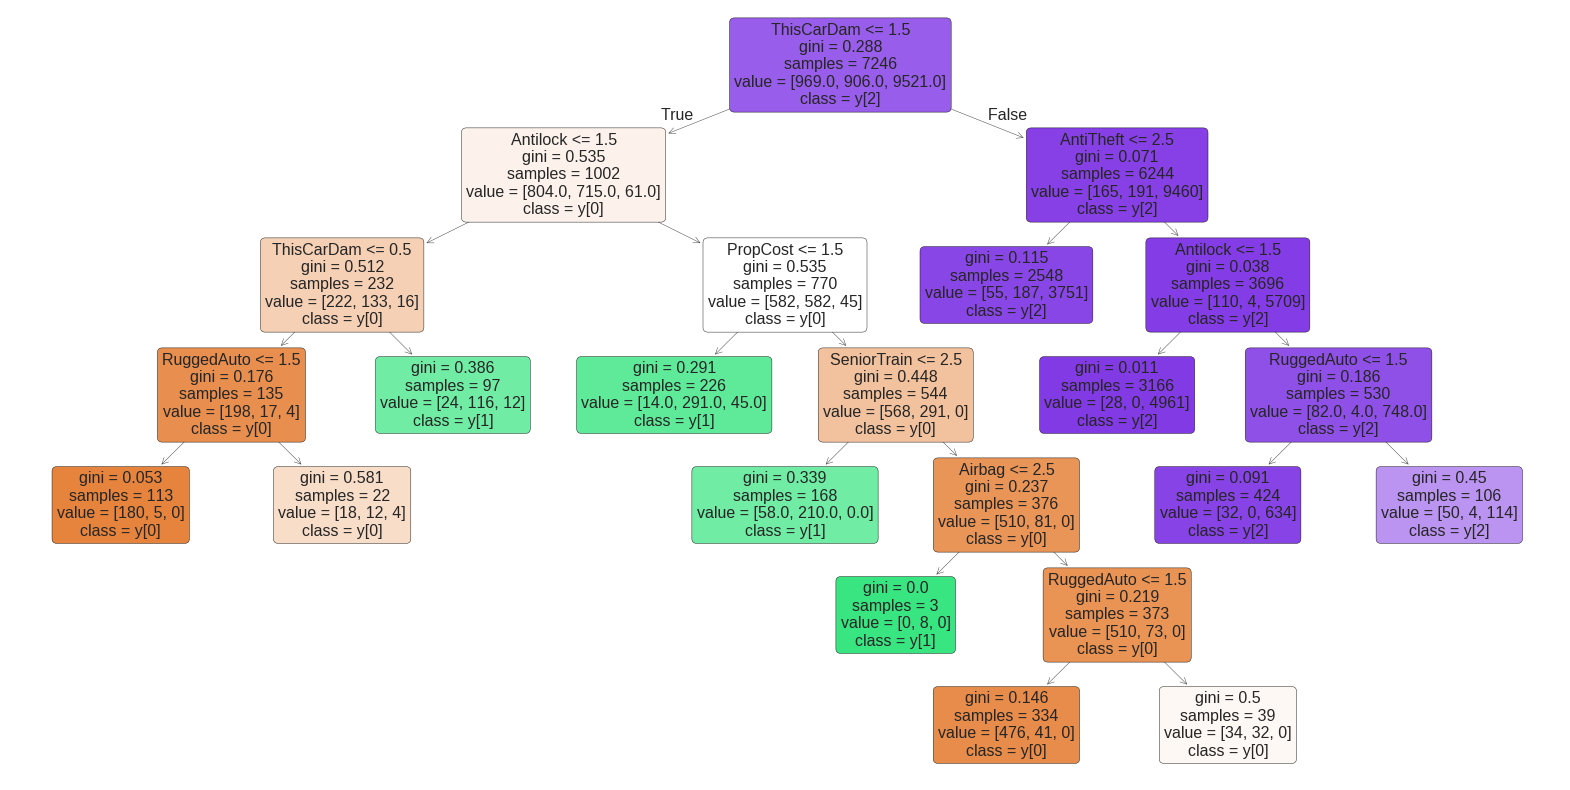

In [ ]:
#impressao
tree_index = 0
tree_to_visualize = modelo.estimators_[tree_index]
plt.figure(figsize=(20,10))
plot_tree(tree_to_visualize, filled=True, feature_names=base.columns[:-1], class_names=True, rounded=True)
plt.show()

In [ ]:
previsoes = modelo.predict(X_teste)

In [ ]:
accuracy = accuracy_score(y_teste, previsoes)
precision = precision_score (y_teste, previsoes, average='weighted')
recall = recall_score (y_teste, previsoes, average='weighted') # weighted = peso
f1 = f1_score (y_teste, previsoes,average='weighted')
print(f'acuracia: {accuracy}, precisão: {precision}, recall: {recall}, f1: {f1} ')

acuracia: 0.9465601965601965, precisão: 0.9445295432909959, recall: 0.9465601965601965, f1: 0.9446638028252415 


In [ ]:
report = classification_report (y_teste, previsoes)
print(report)

              precision    recall  f1-score   support

        Mild       0.93      0.76      0.84       553
    Moderate       0.78      0.75      0.77       473
      Severe       0.97      0.99      0.98      4974

    accuracy                           0.95      6000
   macro avg       0.89      0.83      0.86      6000
weighted avg       0.95      0.95      0.95      6000

